In [2]:
import time
from joblib import Parallel, delayed
import numpy as np

# --- Simulated seed work ---
def simulate_seed_work(seed):
    np.random.seed(seed)
    # Simulate kernel computation + KRR
    # For demonstration, just sleep proportional to seed
    # Replace this with your real computation
    T_train = 100
    T_test = 50
    # Rough time proportional to kernel entries
    num_entries = (T_train*(T_train+1))//2 + T_train*T_test
    sleep_time = num_entries / 100000  # adjust scale for test
    time.sleep(sleep_time)
    # Return dummy test error
    return np.random.rand()

# --- Run seeds sequentially ---
def run_sequential(seeds):
    start = time.time()
    results = [simulate_seed_work(s) for s in seeds]
    end = time.time()
    print(f"Sequential run time: {end-start:.2f} sec")
    return results, end-start

# --- Run seeds in parallel ---
def run_parallel(seeds, n_jobs):
    start = time.time()
    results = Parallel(n_jobs=n_jobs)(
        delayed(simulate_seed_work)(s) for s in seeds
    )
    end = time.time()
    print(f"Parallel run with {n_jobs} cores: {end-start:.2f} sec")
    return results, end-start

# --- Test parameters ---
seeds = list(range(10))  # 10 seeds total

# --- Sequential ---
seq_results, seq_time = run_sequential(seeds)

# --- Parallel versions ---
cores_list = [4, 8, 10]
parallel_times = {}
for n in cores_list:
    par_results, par_time = run_parallel(seeds, n)
    parallel_times[n] = par_time

# --- Summary ---
print("\n--- Summary of runtimes ---")
print(f"Sequential: {seq_time:.2f} sec")
for n, t in parallel_times.items():
    print(f"{n}-core parallel: {t:.2f} sec")


Sequential run time: 1.01 sec
Parallel run with 4 cores: 0.72 sec
Parallel run with 8 cores: 0.69 sec
Parallel run with 10 cores: 0.61 sec

--- Summary of runtimes ---
Sequential: 1.01 sec
4-core parallel: 0.72 sec
8-core parallel: 0.69 sec
10-core parallel: 0.61 sec


In [3]:
import time
from joblib import Parallel, delayed
import numpy as np

# --- Nested train sizes and test points ---
train_sizes = [1, 5, 10, 20, 40, 60, 80, 100]
T_test = 50
seeds = list(range(10))  # 10 seeds total

# --- Simulated kernel + KRR computation per seed ---
def simulate_seed_work(seed):
    np.random.seed(seed)
    
    # --- Simulate largest train kernel computation ---
    T_train_max = max(train_sizes)
    num_entries_train_train = (T_train_max*(T_train_max+1))//2
    num_entries_train_test = T_train_max * T_test
    sleep_time = (num_entries_train_train + num_entries_train_test) / 100000  # scale for test
    time.sleep(sleep_time)
    
    # --- Simulate KRR for nested training sizes ---
    results_per_train = {}
    for T_train in train_sizes:
        # In practice: slice largest kernel matrix for smaller T_train
        # Here: simulate negligible time for slicing
        test_error = np.random.rand()  # dummy test error
        results_per_train[T_train] = test_error
    return results_per_train

# --- Sequential run ---
def run_sequential(seeds):
    start = time.time()
    all_results = [simulate_seed_work(s) for s in seeds]
    end = time.time()
    print(f"Sequential run time: {end-start:.2f} sec")
    return all_results, end-start

# --- Parallel run ---
def run_parallel(seeds, n_jobs):
    start = time.time()
    all_results = Parallel(n_jobs=n_jobs)(
        delayed(simulate_seed_work)(s) for s in seeds
    )
    end = time.time()
    print(f"Parallel run with {n_jobs} cores: {end-start:.2f} sec")
    return all_results, end-start

# --- Test sequential ---
seq_results, seq_time = run_sequential(seeds)

# --- Test parallel versions ---
cores_list = [4, 8, 10]
parallel_times = {}
parallel_results = {}
for n in cores_list:
    par_res, par_time = run_parallel(seeds, n)
    parallel_results[n] = par_res
    parallel_times[n] = par_time

# --- Summary ---
print("\n--- Summary of runtimes ---")
print(f"Sequential: {seq_time:.2f} sec")
for n, t in parallel_times.items():
    print(f"{n}-core parallel: {t:.2f} sec")

# --- Optional: inspect test errors for a seed ---
print("\nExample results for seed 0:", seq_results[0])


Sequential run time: 1.01 sec
Parallel run with 4 cores: 0.76 sec
Parallel run with 8 cores: 0.65 sec
Parallel run with 10 cores: 0.60 sec

--- Summary of runtimes ---
Sequential: 1.01 sec
4-core parallel: 0.76 sec
8-core parallel: 0.65 sec
10-core parallel: 0.60 sec

Example results for seed 0: {1: 0.5488135039273248, 5: 0.7151893663724195, 10: 0.6027633760716439, 20: 0.5448831829968969, 40: 0.4236547993389047, 60: 0.6458941130666561, 80: 0.4375872112626925, 100: 0.8917730007820798}


## Test Parallel for 10 seed 

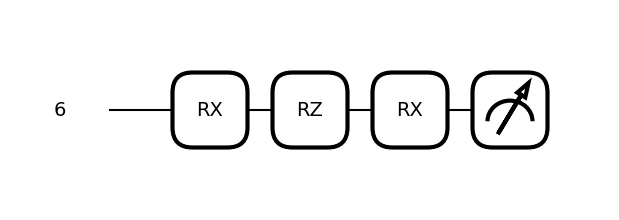

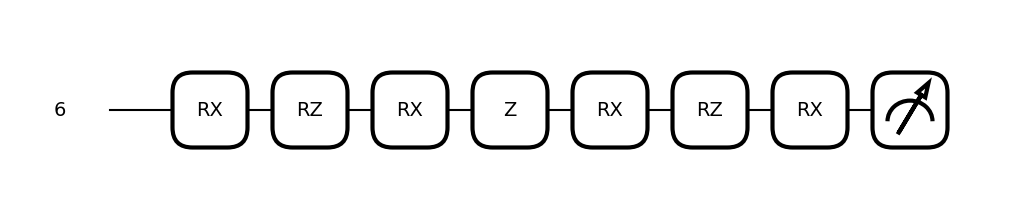

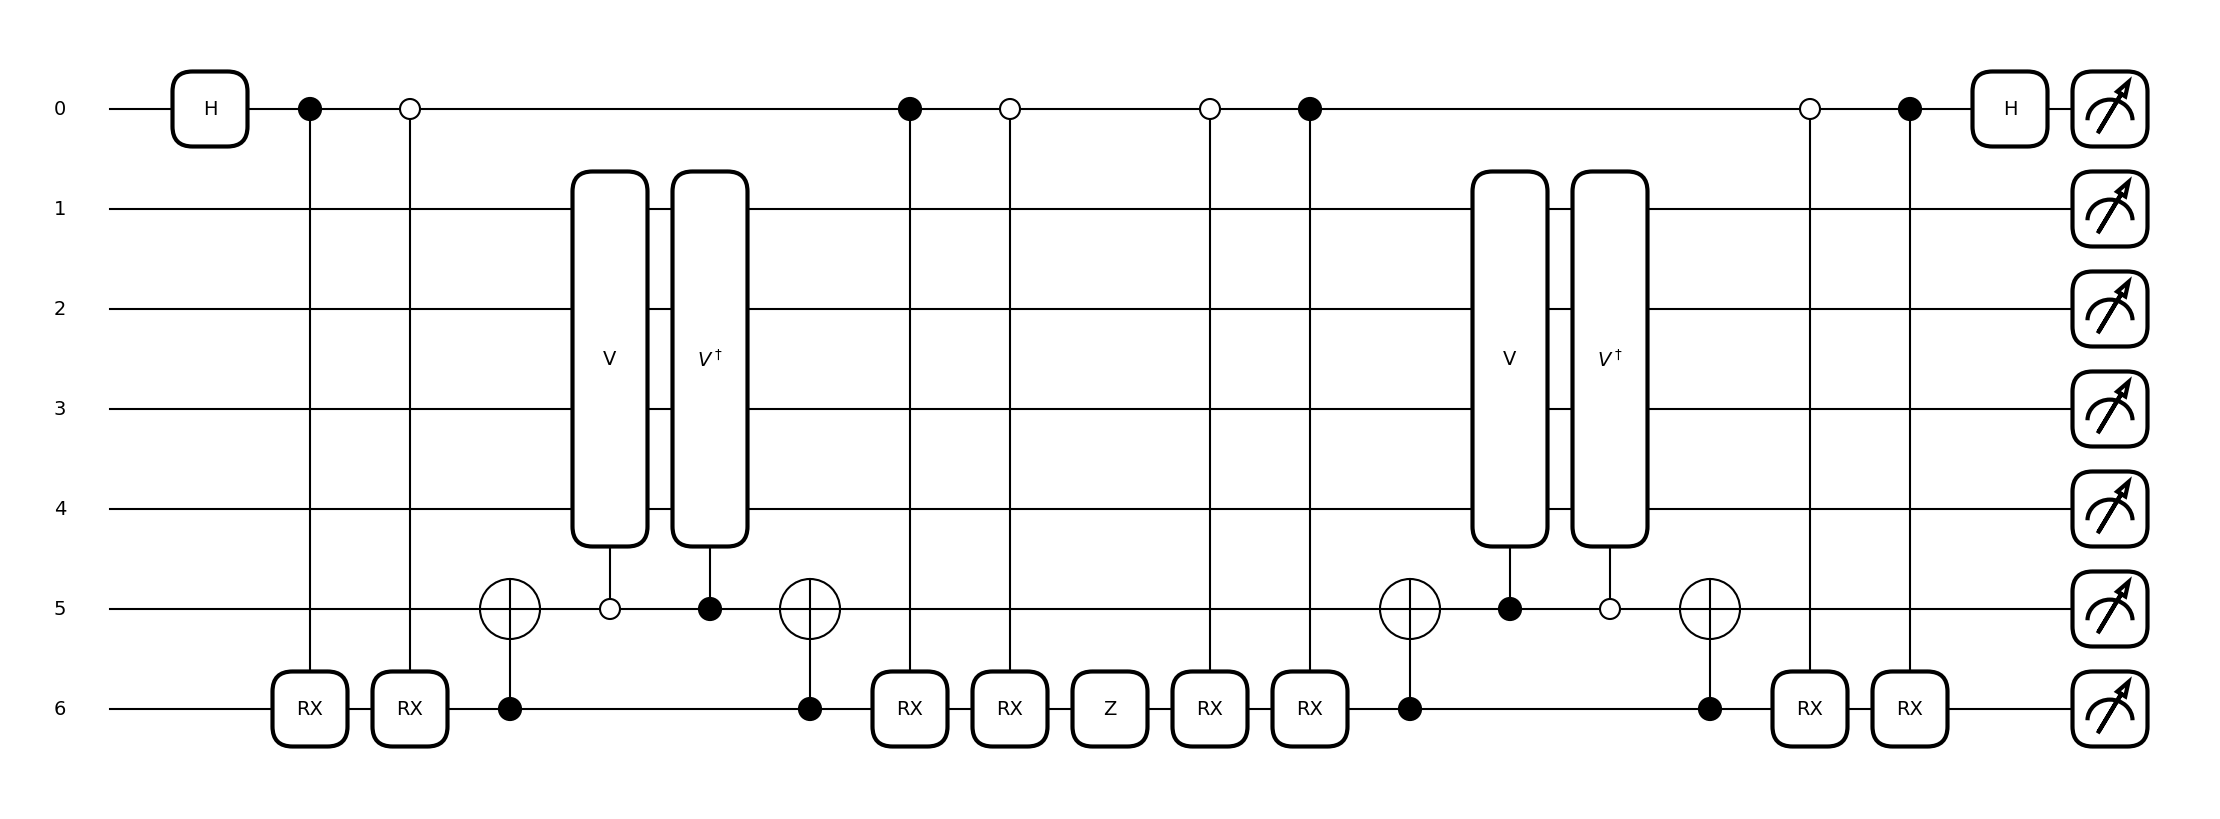

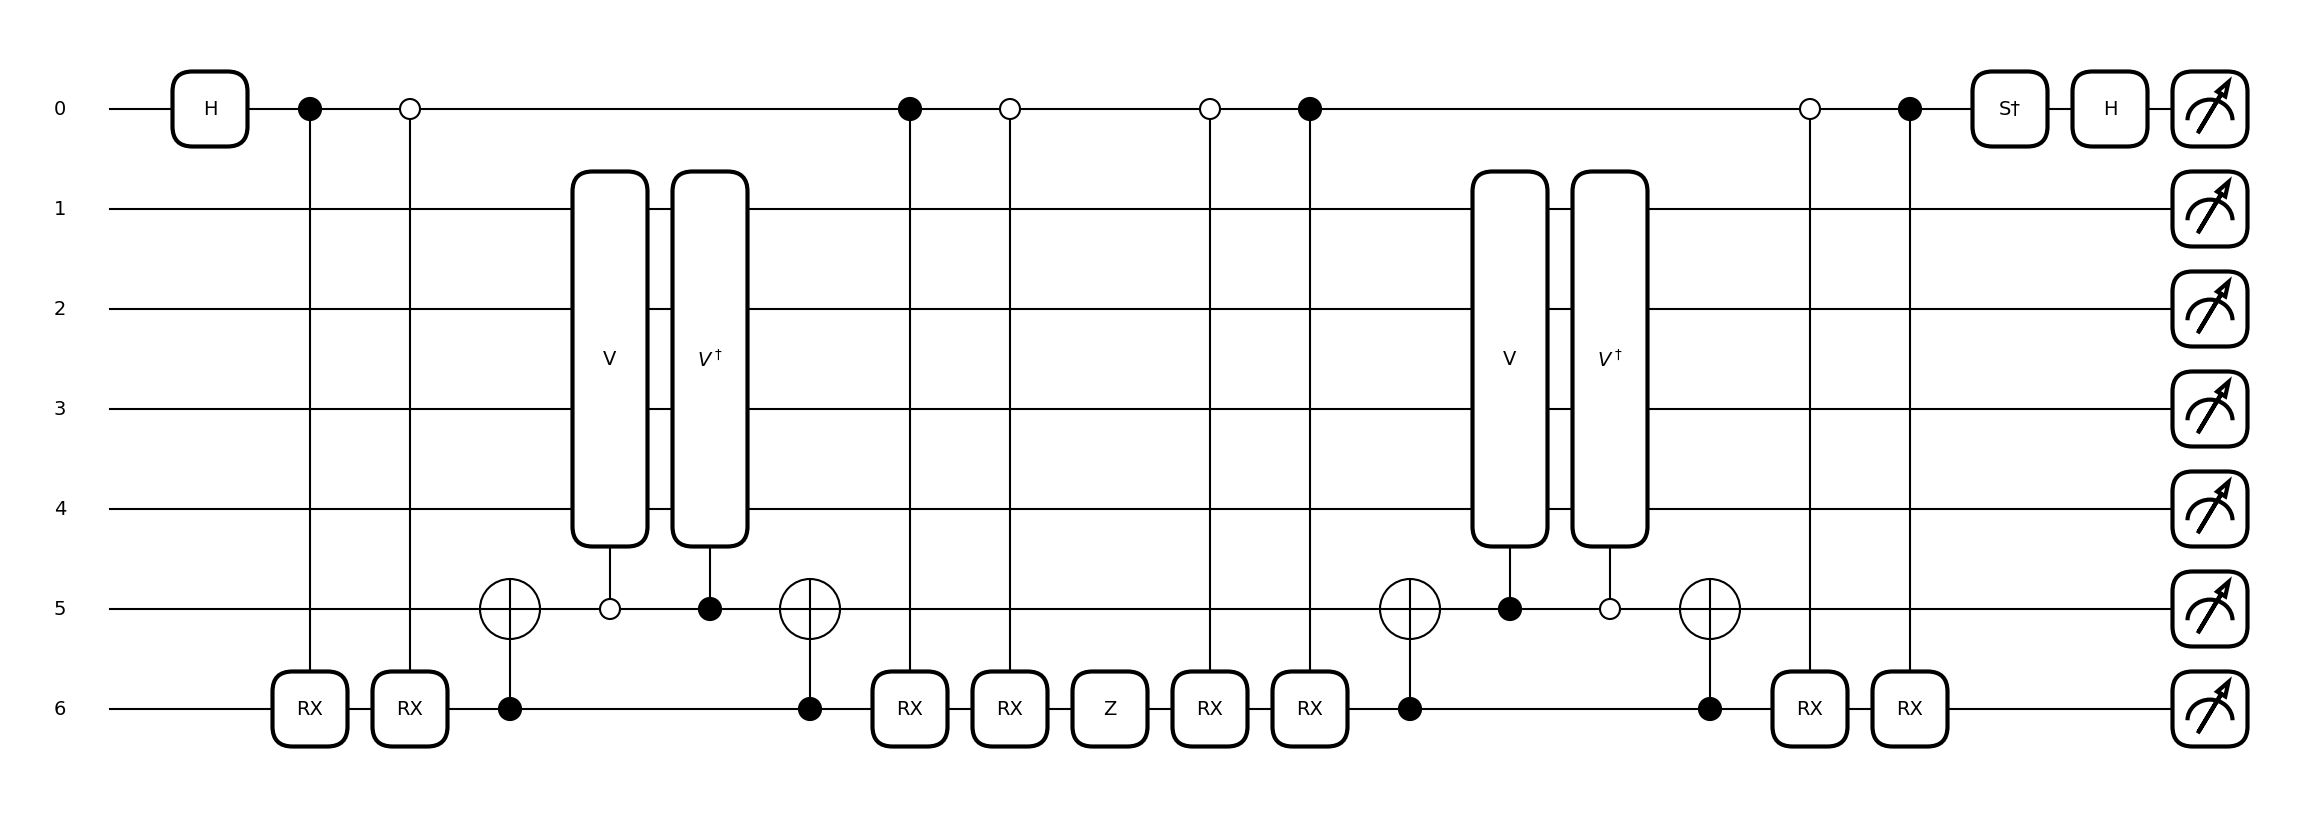

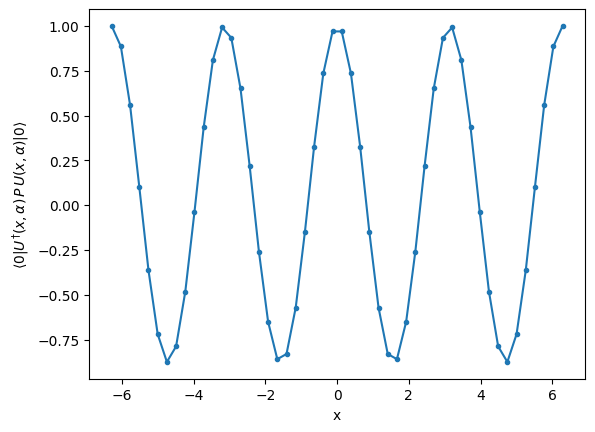


Running: 4 cores


Running seeds (parallel):   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    # name = "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
# start_train = time.time()
# K_train = compute_kernel_matrix_train(X_train, alpha)
# end_train = time.time()
# print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

# start_test = time.time()
# K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
# end_test = time.time()
# print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real
SEEDS = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]
lambdas = [1e-3, 1e-2, 1e-1, 1, 1e1]
n_seeds = len(SEEDS)
n_lam = len(lambdas)

train_mse_all = np.zeros((n_seeds, n_lam))
test_mse_all  = np.zeros((n_seeds, n_lam))
train_r2_all  = np.zeros((n_seeds, n_lam))
test_r2_all   = np.zeros((n_seeds, n_lam))

from joblib import Parallel, delayed
import time
from tqdm_joblib import tqdm_joblib


def run_single_seed(SEED):
    np.random.seed(SEED)

    # Device must be created INSIDE the worker
    dev = qml.device(
        'default.qubit',
        wires=n_total,
        shots=shots,
        seed=SEED
    )

    # Rebind QNode to this device
    local_AuPAu_sample = qml.QNode(AuPAu_sample.func, dev)

    def local_conditional_inner_product(x, x1, α, part="real"):
        samples = local_AuPAu_sample(x, x1, α, part)

        kernel = samples[:, kernel_offset]
        anc = samples[:, anc_offset]
        circ = samples[:, circ_offset]

        mask = (anc == 0) & (circ == 0)
        conditioned = kernel[mask]

        if conditioned.size == 0:
            return 0.0

        zvals = 1 - 2 * conditioned
        expectation = np.mean(zvals)
        fraction_kept = conditioned.size / shots
        return fraction_kept * expectation

    def local_complex_kernel(x, x1, α):
        re = local_conditional_inner_product(x, x1, α, "real")
        im = local_conditional_inner_product(x, x1, α, "imag")
        return re + 1j * im

    # Train / test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, shuffle=True, random_state=SEED
    )

    # Kernel matrices
    n = len(X_train)
    K_train = np.zeros((n, n), dtype=complex)

    for i in range(n):
        for j in range(i, n):
            val = local_complex_kernel(X_train[i], X_train[j], alpha)
            K_train[i, j] = val
            K_train[j, i] = np.conj(val)

    K_train = 0.5 * (K_train + K_train.conj().T)

    K_test = np.zeros((len(X_test), len(X_train)), dtype=complex)
    for i in range(len(X_test)):
        for j in range(len(X_train)):
            K_test[i, j] = local_complex_kernel(X_test[i], X_train[j], alpha)

    # Lambda sweep
    train_mse = []
    test_mse = []

    for lam in lambdas:
        coeffs = manual_krr_fit(K_train, Y_train, lam)
        train_pred = manual_krr_predict(K_train, coeffs)
        test_pred  = manual_krr_predict(K_test, coeffs)

        train_mse.append(mean_squared_error(Y_train, train_pred))
        test_mse.append(mean_squared_error(Y_test, test_pred))

    return np.array(train_mse), np.array(test_mse)

# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------


def benchmark(n_jobs):
    start = time.time()

    if n_jobs == 1:
        results = []
        for seed in tqdm(SEEDS, desc="Running seeds (sequential)"):
            results.append(run_single_seed(seed))
    else:
        with tqdm_joblib(tqdm(desc="Running seeds (parallel)", total=len(SEEDS))):
            results = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(run_single_seed)(seed) for seed in SEEDS
            )

    elapsed = time.time() - start
    return elapsed, results


def aggregate_results(results):
    """
    results: list of (train_mse, test_mse) arrays, one per seed
    """
    train_mse_all = np.stack([r[0] for r in results], axis=0)
    test_mse_all  = np.stack([r[1] for r in results], axis=0)

    return {
        "train_mean": train_mse_all.mean(axis=0),
        "train_std":  train_mse_all.std(axis=0),
        "test_mean":  test_mse_all.mean(axis=0),
        "test_std":   test_mse_all.std(axis=0),
    }
#     "Sequential (1 core)": 1,
configs = {
    "4 cores": 4,
    "8 cores": 8,
    "10 cores": 10,
}

all_results = {}
timings = {}

for label, n_jobs in configs.items():
    print(f"\nRunning: {label}")
    t, results = benchmark(n_jobs)
    timings[label] = t
    all_results[label] = aggregate_results(results)

    print(f"Time: {t:.2f} sec")

for label, res in all_results.items():

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        lambdas,
        res["train_mean"],
        yerr=res["train_std"],
        fmt="o-",
        capsize=4,
        label="Train MSE",
    )

    plt.errorbar(
        lambdas,
        res["test_mean"],
        yerr=res["test_std"],
        fmt="s--",
        capsize=4,
        label="Test MSE",
    )

    plt.xscale("log")
    plt.xlabel(r"Regularization $\lambda$")
    plt.ylabel("Mean Squared Error")
    plt.title(f"KRR MSE over random seeds\n({label})")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.ylim(0,0.002)
    plt.show()
    

plt.figure(figsize=(8, 5))

for label, res in all_results.items():
    plt.plot(
        lambdas,
        res["test_mean"],
        marker="o",
        label=label,
    )

plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Test MSE")
plt.title("Test MSE comparison across parallel settings")
plt.legend()
plt.grid(True)
plt.ylim(0,0.002)
plt.tight_layout()
plt.show()


In [5]:
from tqdm_joblib import tqdm_joblib


c:\Users\rjuya\anaconda3\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


| Cores | Time (min) |
|-------|------------|
| 1     | 53.23      |
| 4     | 38.59      |
| 8     | 24.92      |
| 10    | 14.77      |
